# 08 — Analyse métier : qui cibler, quels segments, quel revenu en jeu

**Questions** :
1. Quelle part des clients est à risque ?
2. Qui cibler en priorité, et avec quelle action ?
3. Quels segments concentrent le risque ?
4. Quel revenu mensuel est en jeu, selon la capacité de la campagne ?

**Données** : `artifacts/scores.parquet`, `artifacts/shap.parquet` et `artifacts/kpis.json`, produits par `make artifacts` (`scripts/build_artifacts.py`). Aucun client n'est noté par un modèle qui l'a vu :
- **train** (80 000 clients) : scores **hors fold** (modèle final réentraîné et recalibré sur les 4 autres folds) ;
- **test** (20 000 clients) : modèle final livré, comme pour un nouveau client. Les seuils des niveaux sont fixés sur le train seul.

**Hypothèses, à dire comme telles** :
- **taux de churn réel : 2 % par mois** (hypothèse D47, sensibilité 1 % et 3 % en section 6). Le jeu de données contient ~50 % de churners : pour parler d'un vrai portefeuille, chaque client est **repondéré** (churners × r/s, non-churners × (1 − r)/(1 − s)), et les effectifs sont exprimés **pour un portefeuille de 100 000 clients** ;
- **taux de succès de l'offre : inconnu**. Aucun départ évité ni revenu préservé n'est présenté comme un résultat ; ils ne sont chiffrés qu'en fonction d'un taux de succès explicitement supposé (D79) ;
- **aucun coût** (offre, contact) n'est supposé.

In [1]:
import json

import numpy as np
import pandas as pd
import plotly.io as pio
from IPython.display import Image, display

from churn.business.actions import FAMILY_LABELS
from churn.business.campaign import campaign_table, group_summary, tier_summary
from churn.business.scoring import TIERS
from churn.charts import TIER_COLORS, grouped_bar_chart, horizontal_bar_chart, publish
from churn.config import get_config
from churn.evaluation.calibration import adjust_prior, population_weights
from churn.logging_setup import setup_logging

setup_logging()
pio.renderers.default = "plotly_mimetype"
pd.set_option("display.width", 220)
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}".replace(",", " "))

cfg = get_config()
scores = pd.read_parquet(cfg.paths.artifacts_dir / "scores.parquet")
factors = pd.read_parquet(cfg.paths.artifacts_dir / "shap.parquet")
kpis = json.loads((cfg.paths.artifacts_dir / "kpis.json").read_text(encoding="utf-8"))
S = kpis["taux_churn_echantillon_train"]
R = cfg.business.real_churn_rate.value
print(f"{len(scores)} clients notés, {scores.shape[1]} colonnes ; {len(factors)} lignes de facteurs")
print(scores["partition"].value_counts().to_string())
print(f"taux réel supposé : {R:.0%} par mois (hypothèse) ; taux de l'échantillon : {S:.4f}")

C:\Users\malek\OneDrive\Desktop\telecom_churn\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100000 clients notés, 34 colonnes ; 800000 lignes de facteurs
partition
train_oof    80000
test         20000
taux réel supposé : 2% par mois (hypothèse) ; taux de l'échantillon : 0.4956


## 0. Contrôles des scores

Les scores hors fold doivent retrouver les performances de la validation croisée (E9 : AUC 0,694) et ceux du test l'évaluation finale (AUC 0,6955). Le taux de churn observé par niveau, dans l'échantillon, doit décroître de High à Low, sur le train **et** sur le test (les seuils ont été fixés sur le train).

In [2]:
pd.DataFrame(kpis["controles"]).T

,clients,auc_proba_calibree,lift@10%_echantillon
test,20 000.000,0.695,1.598
train_oof,80 000.000,0.694,1.570


In [3]:
rates = scores.pivot_table(index="niveau", columns="partition", values="churn", aggfunc="mean",
                           observed=True).reindex(TIERS)
shares = pd.crosstab(scores["niveau"], scores["partition"], normalize="columns").reindex(TIERS)
pd.concat({"churn observé (échantillon)": rates, "part de l'échantillon": shares}, axis=1)

churn observé (échantillon)           part de l'échantillon          
partition                        test train_oof                  test train_oof
niveau                                                                         
High                            0.730     0.723                 0.176     0.174
Medium                          0.586     0.590                 0.240     0.241
Low                             0.373     0.376                 0.564     0.564
Inactif                         0.797     0.773                 0.019     0.020

**Lecture** : les scores hors fold ont une AUC de **0,694** (CV de E9 : 0,694) et ceux du test **0,6955** (évaluation finale de E9) : pas de fuite, et le modèle se comporte pareil sur les deux partitions. Le churn observé décroît nettement de High à Low, **sur le test comme sur le train** (High 73,0 % / 72,3 % ; Medium 58,6 % / 59,0 % ; Low 37,3 % / 37,6 %), avec les mêmes parts de clients : les seuils fixés sur le train tiennent sur des clients jamais vus.

## 1. Quelle part des clients est à risque ?

### Choix des niveaux

On trie les clients **actifs** du train par score hors fold et on les découpe en bandes de 5 % du portefeuille réel. **High** = les 10 % du portefeuille au score le plus élevé (capacité de la campagne, paramètre de la config) ; **Medium** = les bandes suivantes tant que leur lift dépasse 1,2 ; **Low** = le reste. On utilise le lift **de la bande** et non le lift cumulé : le lift cumulé à 40 % inclut les clients High et surestimerait le risque des clients situés à 40 %.

,debut_pct,fin_pct,n,taux,lift,lift_cumule,score_min,niveau
bande,,,,,,,,
0,0.000,5.000,7895,0.061,3.110,3.110,0.698,High
1,5.000,10.000,6052,0.042,2.130,2.620,0.648,High
2,10.000,15.000,5388,0.035,1.780,2.340,0.613,Medium
3,15.000,20.000,4928,0.030,1.540,2.140,0.583,Medium
4,20.000,25.000,4537,0.026,1.330,1.980,0.558,Medium
5,25.000,30.000,4460,0.025,1.290,1.860,0.533,Medium
6,30.000,35.000,4163,0.022,1.130,1.760,0.509,Low
7,35.000,40.000,3940,0.020,1.010,1.660,0.487,Low
8,40.000,45.000,3852,0.019,0.960,1.590,0.466,Low


High : proba calibrée >= 0.6484 ; Medium : >= 0.5327 ; High + Medium = 30 % du portefeuille réel


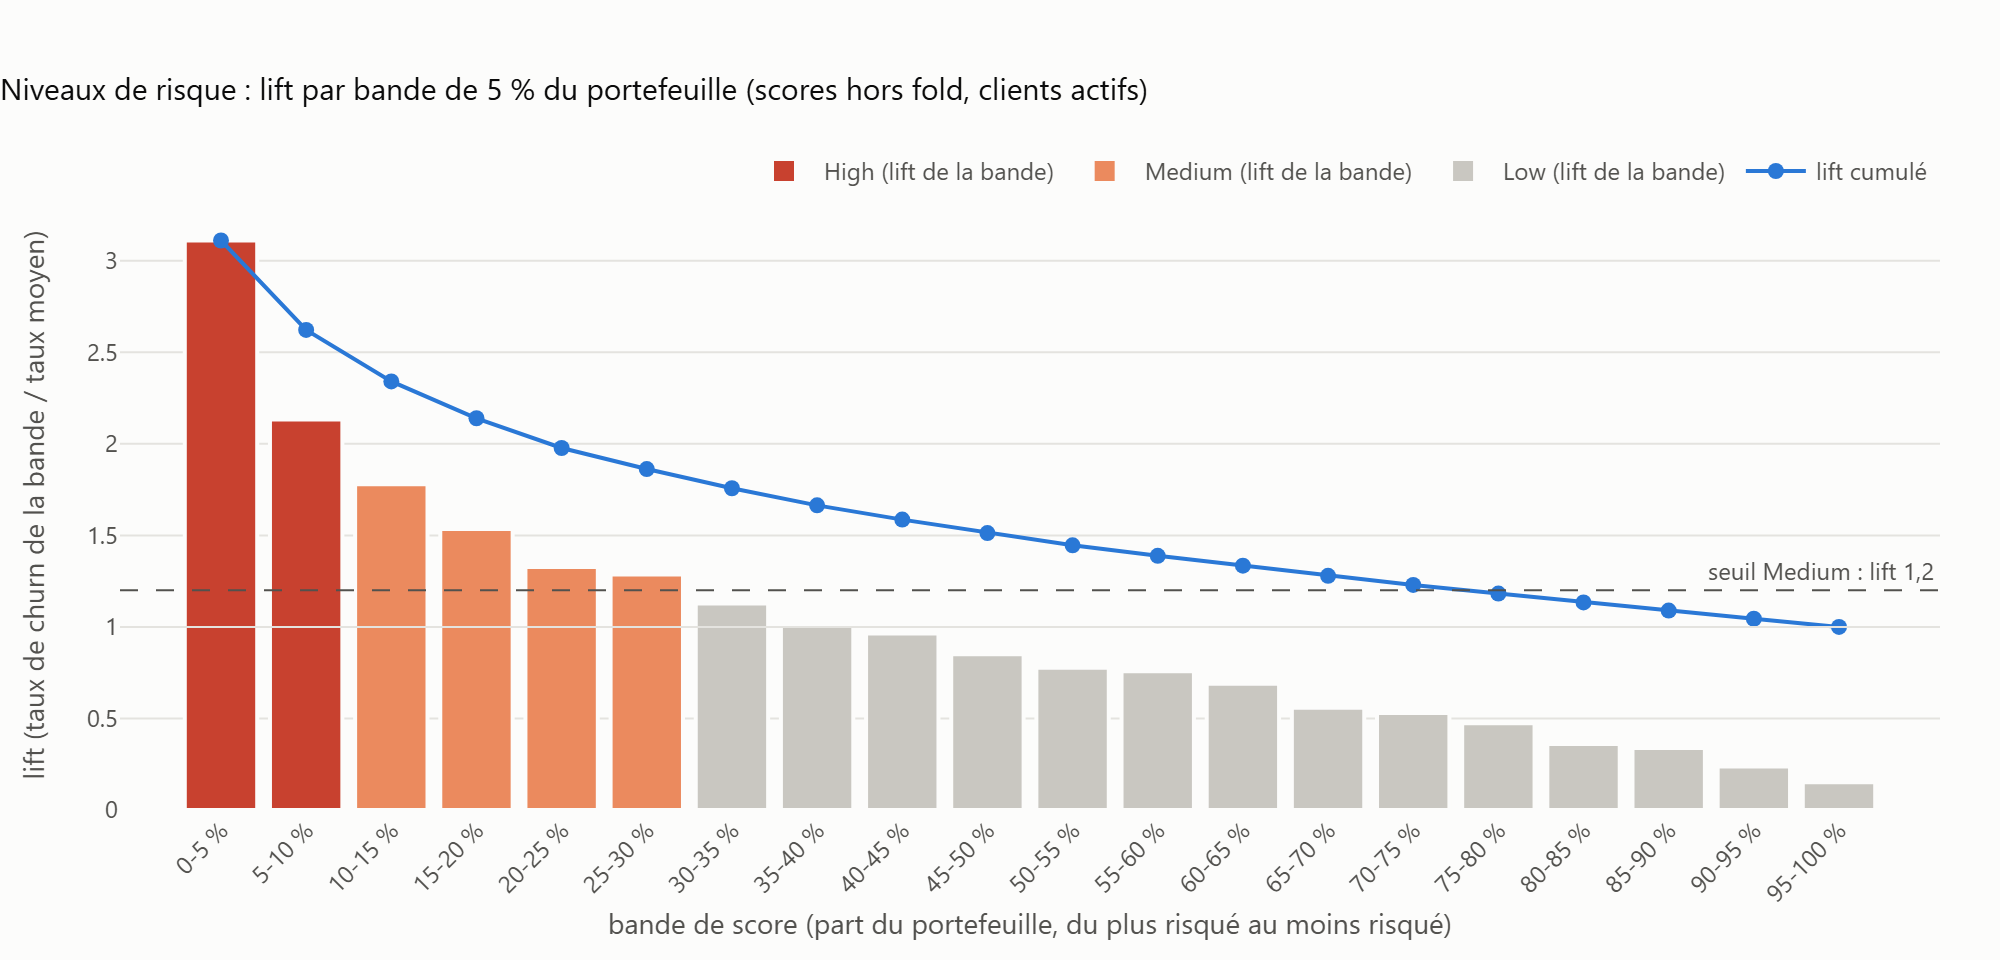

In [4]:
bands = pd.DataFrame(kpis["bandes_lift"]).set_index("bande")
display(bands[["debut_pct", "fin_pct", "n", "taux", "lift", "lift_cumule", "score_min", "niveau"]]
        .round({"taux": 4, "lift": 2, "lift_cumule": 2, "score_min": 3}))
thr = kpis["seuils"]
print(f"High : proba calibrée >= {thr['high']:.4f} ; Medium : >= {thr['medium']:.4f} ; "
      f"High + Medium = {100 * thr['medium_end']:.0f} % du portefeuille réel")
display(Image(filename=str(cfg.paths.figures_dir / "08_tiers_lift.png")))

**Lecture** : les deux premières bandes (High) ont un lift de 3,1 et 2,1. Les quatre suivantes gardent un lift supérieur à 1,2 (de 1,78 à 1,29) : elles forment **Medium**, qui s'arrête à **30 %** du portefeuille, car la bande 30-35 % tombe à 1,13. Au-delà, le risque est proche de la moyenne ou inférieur : **Low**.

Avec le **lift cumulé**, le seuil de 1,2 n'aurait été franchi qu'après 75 % du portefeuille : Medium aurait englobé des clients moins risqués que la moyenne, portés par les clients High du haut de la liste. C'est pourquoi on retient le lift de la bande.

### Répartition du portefeuille

Pour un portefeuille réel de 100 000 clients (repondéré au taux supposé de 2 %). `part_echantillon` rappelle la répartition dans le jeu de données, enrichi en churners : un client sur deux y est un churner, les niveaux élevés y sont donc sur-représentés.

In [5]:
tiers = tier_summary(scores, sample_rate=S)
tiers.round({"clients": 0, "churners_attendus": 0, "revenu_en_jeu": 0, "facture_mensuelle": 0})

,part_portefeuille,part_echantillon,clients_echantillon,proba_reelle_moyenne,churn_observe_echantillon,clients,churners_attendus,revenu_en_jeu,facture_mensuelle,part_churners_attendus,part_revenu_en_jeu
niveau,,,,,,,,,,,
High,0.099,0.175,17472,0.051,0.724,9 876.000,506.000,29 762.000,589 791.000,0.253,0.256
Medium,0.198,0.241,24122,0.029,0.589,19 836.000,572.000,33 198.000,1 150 765.000,0.285,0.286
Low,0.694,0.564,56434,0.012,0.375,69 375.000,859.000,51 839.000,4 149 569.000,0.429,0.446
Inactif,0.009,0.020,1972,0.072,0.778,913.000,65.000,1 364.000,16 296.000,0.033,0.012


In [6]:
q = scores.loc[~scores["inactif"], "proba_reelle"].quantile([0.1, 0.25, 0.5, 0.75, 0.9, 0.99])
print("Probabilité mensuelle corrigée (2 %) des clients actifs de l'échantillon, quantiles :")
print((100 * q).round(2).astype(str).str.replace(".", ",") + " %")

Probabilité mensuelle corrigée (2 %) des clients actifs de l'échantillon, quantiles :
0.100    0,71 %
0.250    1,23 %
0.500    2,03 %
0.750    3,16 %
0.900    4,61 %
0.990    9,49 %
Name: proba_reelle, dtype: str


**Réponse** : sur un portefeuille réel de 100 000 clients (hypothèse de 2 % de churn par mois) :

- **High : 9 876 clients (9,9 %)**, risque mensuel moyen **5,1 %**, soit 2,6 fois la moyenne ; ils portent **25 %** des départs attendus ;
- **Medium : 19 836 clients (19,8 %)**, risque moyen **2,9 %** ; 29 % des départs attendus ;
- **Low : 69 375 clients (69,4 %)**, risque moyen **1,2 %** ; mais, par leur nombre, **43 %** des départs attendus ;
- **Inactifs : 913 clients (0,9 %)**, risque moyen **7,2 %** (le plus élevé), 3 % des départs attendus.

Le total des départs attendus (2 002 pour 100 000) retrouve le taux supposé de 2 % : les probabilités corrigées sont cohérentes. Aucun client n'est « sûr de partir » : même dans le 1 % le plus risqué, la probabilité mensuelle ne dépasse pas ~9,5 %. Le ciblage **concentre** le risque sans jamais isoler les churners : un ciblage limité à 10 % du portefeuille laisse de côté les trois quarts des départs.

## 2. Qui cibler, et avec quelle action ?

### Profil des niveaux

Médianes des variables d'affichage par niveau (échantillon, tous clients).

In [7]:
display_cols = ["months", "eqpdays", "mou_Mean", "change_mou", "totmrc_Mean", "ovrrev_Mean",
                "hnd_price", "custcare_Mean", "drop_vce_Mean", "actvsubs", "rev_Mean"]
profile = scores.groupby("niveau", observed=True)[display_cols].median().reindex(TIERS)
profile["fin_engagement_%"] = (scores.assign(fe=scores["months"].isin([11, 12]))
                               .groupby("niveau", observed=True)["fe"].mean().reindex(TIERS) * 100)
profile.T

niveau,High,Medium,Low,Inactif
months,15.000,17.000,17.000,20.000
eqpdays,377.000,409.000,272.000,475.500
mou_Mean,273.750,326.750,411.500,0.000
change_mou,-45.000,-12.500,0.750,0.000
totmrc_Mean,39.990,39.990,44.990,16.990
ovrrev_Mean,2.712,2.450,0.600,0.000
hnd_price,59.990,79.990,129.990,59.990
custcare_Mean,0.000,0.000,0.000,0.000
drop_vce_Mean,3.000,3.000,3.333,0.000
actvsubs,1.000,1.000,1.000,1.000


### Actions suggérées

L'action vient de la famille du **facteur actionnable dominant** (celui qui, selon le modèle, augmente le plus le risque parmi les facteurs sur lesquels on peut agir, D83-D85). Les clients Low n'ont pas d'action de campagne ; les inactifs relèvent d'une vérification de ligne ou d'une reconquête (D86).

In [8]:
targeted = scores[scores["niveau"].isin(["High", "Medium", "Inactif"])]
actions = group_summary(targeted, "action", sample_rate=S)
actions = actions.sort_values("clients", ascending=False)
actions[["clients", "churners_attendus", "revenu_en_jeu", "proba_reelle_moyenne"]]

,clients,churners_attendus,revenu_en_jeu,proba_reelle_moyenne
action,,,,
Offre de renouvellement du terminal,36 767.507,1 160.615,57 197.803,0.032
Offre adaptée à l'usage,26 840.542,1 106.057,63 956.108,0.041
Offre de réengagement,23 306.541,909.828,54 047.215,0.039
Changement de forfait,7 026.537,246.543,22 998.042,0.035
Vérifier la ligne / reconquête,2 981.016,213.715,4 452.520,0.072
Contact de fidélisation (offre multi-lignes),2 478.879,78.888,5 814.704,0.032
Geste commercial + ticket technique,598.978,18.229,1 570.571,0.030


In [9]:
mix = pd.crosstab(scores["action"], scores["niveau"]).reindex(columns=["High", "Medium", "Inactif"])
mix = mix[mix.sum(axis=1) > 0].sort_values("High", ascending=False)
mix_pct = 100 * mix / mix.sum()
fig = grouped_bar_chart(mix_pct[["High", "Medium"]].round(1),
                        "Action suggérée : répartition des clients High et Medium (échantillon)",
                        "part des clients du niveau (%)", fmt=".1f",
                        colors={"High": TIER_COLORS["High"], "Medium": TIER_COLORS["Medium"]})
publish(fig, "08_actions")
mix

niveau,High,Medium,Inactif
action,,,
Offre adaptée à l'usage,7030,5618,0
Offre de réengagement,5639,4848,0
Offre de renouvellement du terminal,3374,10964,0
Changement de forfait,1142,1828,0
Contact de fidélisation (offre multi-lignes),251,692,0
Geste commercial + ticket technique,36,172,0
Vérifier la ligne / reconquête,0,0,1972


### Raisons les plus fréquentes chez les clients High

Famille de chacune des 3 raisons actionnables affichées (tableau long des facteurs SHAP) et facteur de contexte le plus fréquent.

In [10]:
high_ids = scores.loc[scores["niveau"] == "High", cfg.data.id_col]
f_high = factors[factors[cfg.data.id_col].isin(high_ids)]
top3_action = (f_high[f_high["actionnable"] & (f_high["contribution"] > 0)]
               .sort_values(["Customer_ID", "rang"]).groupby("Customer_ID").head(3))
fam = top3_action["libelle"].value_counts().head(10)
share = (100 * fam / high_ids.size).round(1)
publish(horizontal_bar_chart(share, "Clients High : facteurs actionnables parmi leurs 3 raisons",
                             "part des clients High (%)", fmt=".1f"), "08_raisons_high")
ctx = f_high[~f_high["actionnable"]].sort_values(["Customer_ID", "rang"]).groupby("Customer_ID").head(1)
print("Facteur de contexte principal des clients High (part des clients) :")
print((100 * ctx["libelle"].value_counts(normalize=True).head(5)).round(1).to_string())

Facteur de contexte principal des clients High (part des clients) :
libelle
Classe de crédit            38.500
Région                      30.500
Durée de résidence          20.600
Ancienneté                   8.000
Type de zone d'habitation    2.100


### Exemples de fiches client (High)

Ce que verra un conseiller : score, niveau, 3 raisons actionnables, action, contexte.

In [11]:
cols = ["Customer_ID", "partition", "proba_reelle", "niveau", "raison_1", "raison_2", "raison_3",
        "action", "contexte_1", "revenu_en_jeu"]
examples = (scores[(scores["niveau"] == "High") & (scores["partition"] == "test")]
            .sort_values("proba_reelle", ascending=False).iloc[[0, 50, 200, 800, 1500]][cols])
examples.assign(proba_reelle=(100 * examples["proba_reelle"]).round(1)).T

,92834,85600,83064,87747,88943
Customer_ID,1035033,1075002,1060455,1072931,1090660
partition,test,test,test,test,test
proba_reelle,22.100,14.000,9.800,6.400,5.100
niveau,High,High,High,High,High
raison_1,Évolution de l'usage non mesurée,Évolution de l'usage non mesurée,Terminal ancien : 10 mois,Fin d'engagement : 12 mois d'ancienneté,Fin d'engagement : 11 mois d'ancienneté
raison_2,Usage en baisse de 100 % (3 derniers mois contre 6 mois),Fin d'engagement : 12 mois d'ancienneté,Usage en baisse de 45 % (3 derniers mois contre 6 mois),Terminal à 30 $,Terminal ancien : 10 mois
raison_3,Minutes d'appel : 2 par mois,Usage en baisse de 46 % (3 derniers mois contre 6 mois),Minutes d'appel : 72 par mois,Minutes d'appel : 55 par mois,Usage en baisse de 205 minutes par mois
action,Offre adaptée à l'usage,Offre adaptée à l'usage,Offre de renouvellement du terminal,Offre de réengagement,Offre de réengagement
contexte_1,Classe de crédit BA (augmente le risque),Classe de crédit AA (augmente le risque),Région : South Florida (augmente le risque),Classe de crédit AA (augmente le risque),Classe de crédit AA (augmente le risque)
revenu_en_jeu,1.797,9.733,3.459,2.119,5.491


**Réponse** : les **clients High**, dont le profil type est le suivant :

- **usage en baisse** : −45 minutes par mois en médiane, contre +1 chez les Low ;
- **terminal ancien et bon marché** : 377 jours et 60 $ en médiane, contre 272 jours et 130 $ ;
- **en fin d'engagement** : 37 % d'entre eux ont 11-12 mois d'ancienneté, contre 4 % des Low ;
- **forfait plus petit, avec plus de dépassements.**

**Actions** : pour les clients High, la première action est l'**offre adaptée à l'usage** (7 030 clients de l'échantillon). Viennent ensuite l'**offre de réengagement** (5 639) et le **renouvellement du terminal** (3 374). Chez les Medium, le renouvellement du terminal domine (10 964). Tous les clients ciblés ont au moins un facteur actionnable qui augmente leur risque, donc l'action par défaut (« contact de fidélisation ») n'est jamais utilisée. Le « geste commercial + ticket technique » reste rare (36 High) : la qualité réseau pèse peu dans le modèle (E11).

**Contexte** : pour 38 % des clients High, le facteur de contexte principal est la classe de crédit, et pour 30 % la région. Ces facteurs sont affichés pour information, sans action associée (D83).

**Limite visible dans les fiches** : les clients High les plus risqués ont souvent un usage quasi nul (2 minutes par mois) ou une évolution d'usage non mesurée. Ils ne sont pas classés « inactifs », car leur `mou_Mean` n'est pas exactement nul, mais ils en sont proches : 673 clients High ont moins de 10 minutes par mois. Pour eux, l'« offre adaptée à l'usage » est à relire avec la même prudence que pour les inactifs.

## 3. Quels segments concentrent le risque ?

Segments comportementaux K-means (E4b, appris sans la cible sur le train). Pour chaque segment : poids dans le portefeuille réel, risque moyen, part des clients High, churners attendus et revenu en jeu.

In [12]:
w = population_weights(scores["churn"], R, S)
seg_tiers = pd.crosstab(scores["segment"], scores["niveau"], values=w, aggfunc="sum",
                        normalize="index").reindex(columns=TIERS)
seg = group_summary(scores, "segment", sample_rate=S)
seg["part_high_%"] = 100 * seg_tiers["High"].reindex(seg.index)
seg = seg.sort_values("proba_reelle_moyenne", ascending=False)
seg[["part_portefeuille", "proba_reelle_moyenne", "churn_observe_echantillon", "part_high_%",
     "churners_attendus", "part_churners_attendus", "revenu_en_jeu", "part_revenu_en_jeu"]]

,part_portefeuille,proba_reelle_moyenne,churn_observe_echantillon,part_high_%,churners_attendus,part_churners_attendus,revenu_en_jeu,part_revenu_en_jeu
segment,,,,,,,,
Clients anciens à terminal ancien et bon marché,0.177,0.027,0.559,16.099,475.955,0.238,19 701.606,0.170
Lignes secondaires à petit forfait,0.081,0.025,0.546,11.075,202.832,0.101,3 577.415,0.031
Gros consommateurs en baisse d'usage,0.212,0.020,0.494,10.558,415.309,0.207,36 826.533,0.317
"Usage modéré, clients récents",0.321,0.017,0.467,7.854,558.098,0.279,24 178.448,0.208
Gros consommateurs en hausse d'usage,0.210,0.017,0.454,6.558,350.048,0.175,31 878.439,0.274


Répartition des niveaux dans chaque segment (portefeuille réel repondéré, %) :

In [13]:
(100 * seg_tiers.loc[seg.index]).round(1)

niveau,High,Medium,Low,Inactif
segment,,,,
Clients anciens à terminal ancien et bon marché,16.100,33.000,49.500,1.400
Lignes secondaires à petit forfait,11.100,21.300,62.200,5.400
Gros consommateurs en baisse d'usage,10.600,18.800,70.500,0.100
"Usage modéré, clients récents",7.900,15.600,76.000,0.600
Gros consommateurs en hausse d'usage,6.600,15.700,77.700,0.000


In [14]:
seg_actions = pd.crosstab(scores.loc[scores["niveau"] == "High", "segment"],
                         scores.loc[scores["niveau"] == "High", "action"], normalize="index")
(100 * seg_actions).round(0)

action,Changement de forfait,Contact de fidélisation (offre multi-lignes),Geste commercial + ticket technique,Offre adaptée à l'usage,Offre de renouvellement du terminal,Offre de réengagement
segment,,,,,,
Clients anciens à terminal ancien et bon marché,7.000,1.000,0.000,45.000,47.000,0.000
Gros consommateurs en baisse d'usage,3.000,2.000,0.000,55.000,6.000,34.000
Gros consommateurs en hausse d'usage,26.000,3.000,1.000,1.000,16.000,53.000
Lignes secondaires à petit forfait,3.000,3.000,0.000,52.000,12.000,31.000
"Usage modéré, clients récents",1.000,1.000,0.000,38.000,7.000,53.000


**Réponse** :

- **Clients anciens à terminal ancien et bon marché** : risque moyen le plus élevé (**2,7 %**). **16 %** de ces clients sont High, contre 10 % en moyenne, et le segment porte 24 % des départs attendus pour 18 % du portefeuille. Les actions naturelles sont le renouvellement du terminal (47 % de leurs clients High) et une offre adaptée à l'usage (45 %).
- **Gros consommateurs en baisse d'usage** : risque moyen (2,0 %), mais **32 % du revenu en jeu** pour 21 % du portefeuille, car leur facture est élevée. C'est le segment le plus important **en revenu**. Actions : offre adaptée à l'usage (55 %) et réengagement (34 %).
- **Lignes secondaires à petit forfait** : risque élevé (2,5 %) et **5,4 % d'inactifs**, six fois plus que la moyenne (0,9 %). Le revenu en jeu y est faible (3 %) : la priorité est de vérifier les lignes plutôt que de proposer une offre.
- **Gros consommateurs en hausse d'usage** et **usage modéré, clients récents** : risque le plus faible (1,7 %). Pour les clients High de ces segments, la fin d'engagement domine (53 %), avec une offre de réengagement. Les gros consommateurs en hausse ont aussi des dépassements : changement de forfait pour 26 % d'entre eux.

Le choix du segment prioritaire dépend donc de l'objectif : **nombre de départs** (clients anciens à terminal ancien) ou **revenu** (gros consommateurs en baisse d'usage).

## 4. Quel revenu est en jeu ?

**Revenu mensuel en jeu** d'un client = probabilité corrigée (2 %) × facture mensuelle (`rev_Mean`) : le revenu qu'on s'attend à perdre le mois prochain si rien n'est fait. Ce n'est pas un revenu préservé. Portefeuille de 100 000 clients.

In [15]:
total = tiers["revenu_en_jeu"].sum()
print(f"Revenu mensuel en jeu, portefeuille de 100 000 clients : {total:,.0f} $".replace(",", " "))
bill = tiers["facture_mensuelle"].sum()
print(f"Facture mensuelle totale du même portefeuille : {bill:,.0f} $ ; part en jeu : {total / bill:.2%}".replace(",", " "))
tiers[["clients", "churners_attendus", "part_churners_attendus", "revenu_en_jeu", "part_revenu_en_jeu"]]

Revenu mensuel en jeu  portefeuille de 100 000 clients : 116 162 $
Facture mensuelle totale du même portefeuille : 5 906 420 $ ; part en jeu : 1.97%


,clients,churners_attendus,part_churners_attendus,revenu_en_jeu,part_revenu_en_jeu
niveau,,,,,
High,9 875.707,506.406,0.253,29 761.590,0.256
Medium,19 836.038,571.632,0.285,33 197.970,0.286
Low,69 375.329,858.755,0.429,51 839.312,0.446
Inactif,912.926,65.449,0.033,1 363.570,0.012


### Tableau de campagne

Les clients **actifs** sont ciblés par score décroissant jusqu'à la capacité. `churners_hasard` = même nombre de clients tirés au hasard (2 % de churners). `churners_observes` = contrôle par les étiquettes historiques repondérées (il doit être proche de `churners_attendus` si les probabilités sont bien calibrées). Les inactifs sont comptés à part.

In [16]:
campaign = campaign_table(scores, sample_rate=S)
campaign.set_index("groupe").round({"clients": 0, "churners_attendus": 0, "churners_hasard": 0,
                                    "churners_observes": 0, "revenu_en_jeu": 0, "facture_mensuelle": 0})

,capacite,clients,churners_attendus,churners_hasard,facteur_vs_hasard,churners_observes,revenu_en_jeu,facture_mensuelle,part_churners_attendus,part_revenu_en_jeu
groupe,,,,,,,,,,
Top 5 % (actifs),0.050,5 001.000,308.000,100.000,3.079,308.000,17 748.000,295 007.000,0.154,0.153
Top 10 % (actifs),0.100,10 000.000,511.000,200.000,2.555,515.000,30 059.000,597 880.000,0.255,0.259
Top 20 % (actifs),0.200,20 001.000,831.000,400.000,2.076,837.000,48 821.000,1 185 838.000,0.415,0.420
Inactifs (vérification / reconquête),NaN,913.000,65.000,18.000,3.585,62.000,1 364.000,16 296.000,0.033,0.012
Portefeuille entier,NaN,100 000.000,2 002.000,2 000.000,1.001,2 000.000,116 162.000,5 906 420.000,1.000,1.000


In [17]:
plot = campaign[campaign["capacite"].notna()].set_index("groupe")[["churners_attendus", "churners_hasard"]]
plot.columns = ["ciblage par le modèle", "ciblage au hasard"]
fig = grouped_bar_chart(plot.round(0), "Churners attendus parmi les clients ciblés (portefeuille de 100 000 clients, taux réel supposé 2 %)",
                        "churners attendus sur un mois", fmt=".0f",
                        colors={"ciblage par le modèle": TIER_COLORS["High"], "ciblage au hasard": TIER_COLORS["Low"]})
publish(fig, "08_campagne")

**Réponse** (portefeuille de 100 000 clients, taux réel supposé de 2 %, sans aucun coût) :

- **Revenu mensuel en jeu : environ 116 000 $** par mois, soit 2,0 % de la facture mensuelle du portefeuille (5,9 M$).
- En ciblant les **10 % les plus risqués** (10 000 clients actifs) :
  - **511 churners attendus**, contre 200 pour un ciblage au hasard (facteur **2,6**), soit **environ 51 futurs churners pour 1 000 clients contactés, contre 20 au hasard** ;
  - **30 000 $ de revenu mensuel en jeu**, soit 26 % du total.
- À 5 % de capacité : 308 churners attendus (facteur 3,1) et 17 700 $ en jeu. À 20 % : 831 churners (facteur 2,1) et 48 800 $.
- Chaque point de capacité supplémentaire capte moins que le précédent : c'est la décroissance du lift par bande.
- **Contrôle** : les churners observés dans l'historique repondéré (515 dans le top 10 %) sont proches des churners attendus (511). Les probabilités corrigées sont donc cohérentes avec les étiquettes, sous l'hypothèse de 2 %.
- **Inactifs**, comptés à part : 913 clients, 65 départs attendus, mais seulement **1 364 $** en jeu (1,2 % du total). Leur facture est faible (17 $ en médiane) : c'est une question de **reconquête ou de nettoyage du parc** plus que de revenu.

**Écart avec E10** : E10 annonçait environ 56 churners pour 1 000 clients contactés (test, top 10 % de **tous** les clients). Ici, les inactifs sont retirés de la campagne (D86) : on obtient environ **51** churners attendus pour 1 000 (53 observés sur le test). Ce sont des départs **atteints** par le ciblage, pas des départs **évités**.

## 5. Départs évités : uniquement sous hypothèse de taux de succès

Le modèle dit **qui** risque de partir, pas si l'offre le retiendra. Départs évités = churners ciblés × **taux de succès de l'offre**, inconnu tant qu'il n'est pas mesuré (groupe témoin, A/B test). Les chiffres ci-dessous sont des **illustrations** pour des taux de succès **supposés** de 10, 20 et 30 % ; ce ne sont pas des résultats.

In [18]:
rows = []
for _, c in campaign[campaign["capacite"].notna()].iterrows():
    for success in (0.10, 0.20, 0.30):
        rows.append({"capacité": c["groupe"], "taux de succès SUPPOSÉ": f"{success:.0%}",
                     "départs évités (illustration)": c["churners_attendus"] * success,
                     "revenu mensuel préservé (illustration, $)": c["revenu_en_jeu"] * success})
order = campaign.loc[campaign["capacite"].notna(), "groupe"].tolist()
pd.DataFrame(rows).pivot(index="capacité", columns="taux de succès SUPPOSÉ").reindex(order).round(0)

départs évités (illustration)                 revenu mensuel préservé (illustration, $)                     
taux de succès SUPPOSÉ                           10%     20%     30%                                       10%       20%        30%
capacité                                                                                                                           
Top 5 % (actifs)                              31.000  62.000  92.000                                 1 775.000 3 550.000  5 324.000
Top 10 % (actifs)                             51.000 102.000 153.000                                 3 006.000 6 012.000  9 018.000
Top 20 % (actifs)                             83.000 166.000 249.000                                 4 882.000 9 764.000 14 646.000

## 6. Sensibilité au taux de churn réel supposé (1 %, 2 %, 3 %)

Le classement et les niveaux ne dépendent pas (ou très peu) de l'hypothèse ; les montants, eux, y sont presque proportionnels.

In [19]:
sens = []
for r in cfg.business.real_churn_rate.sensitivity:
    s_r = scores.assign(proba_reelle=adjust_prior(scores["proba_calibree"], r, S))
    s_r["revenu_en_jeu"] = s_r["proba_reelle"] * s_r["rev_Mean"].fillna(0)
    t = campaign_table(s_r, real_rate=r, sample_rate=S).set_index("groupe")
    top10 = t.loc["Top 10 % (actifs)"]
    sens.append({"taux réel supposé": f"{r:.0%}", "churners attendus (top 10 %)": top10["churners_attendus"],
                 "au hasard": top10["churners_hasard"], "facteur vs hasard": top10["facteur_vs_hasard"],
                 "revenu en jeu top 10 % ($/mois)": top10["revenu_en_jeu"],
                 "revenu en jeu portefeuille ($/mois)": t.loc["Portefeuille entier", "revenu_en_jeu"],
                 "inactifs (clients)": t.loc["Inactifs (vérification / reconquête)", "clients"]})
pd.DataFrame(sens).set_index("taux réel supposé")

,churners attendus (top 10 %),au hasard,facteur vs hasard,revenu en jeu top 10 % ($/mois),revenu en jeu portefeuille ($/mois),inactifs (clients)
taux réel supposé,,,,,,
1%,258.421,100.000,2.584,15 199.091,58 099.253,890.660
2%,510.998,200.009,2.555,30 059.400,116 162.442,912.926
3%,757.851,300.031,2.526,44 542.829,174 195.856,935.193


**Lecture** :

- **Classement** : le facteur par rapport au hasard est quasi constant (**2,58 / 2,56 / 2,53** à 1 %, 2 % et 3 %). Les niveaux et le choix des clients à cibler ne dépendent donc presque pas de l'hypothèse de taux réel.
- **Montants** : le nombre de churners et le revenu en jeu sont presque **proportionnels** au taux supposé. Le revenu en jeu du portefeuille va de 58 000 $ par mois à 1 % jusqu'à 174 000 $ par mois à 3 %.

Tout chiffre en churners ou en dollars doit donc être présenté avec son hypothèse.

## Conclusion

1. **Quelle part des clients est à risque ?**
   - **High** : 10 % du portefeuille (capacité de campagne), risque mensuel moyen 5,1 %, 2,6 fois la moyenne.
   - **Medium** : 20 % de plus, dont le lift de bande reste supérieur à 1,2.
   - **Low** : 69 %, dont le risque est proche de la moyenne ou inférieur.
   - **Inactifs** : 0,9 %, avec le risque le plus élevé (7,2 %), traités à part.
2. **Qui cibler ?** Les clients High : usage en baisse, terminal ancien et bon marché, fin d'engagement. Ils reçoivent surtout une offre adaptée à l'usage, une offre de réengagement ou un renouvellement de terminal, chaque fois déduits d'un facteur **actionnable**.
3. **Quels segments ?**
   - En **nombre de départs** : les clients anciens à terminal ancien (risque 2,7 %).
   - En **revenu** : les gros consommateurs en baisse d'usage (32 % du revenu en jeu).
   - Les lignes secondaires : 5,4 % d'inactifs, à vérifier en priorité.
4. **Quel revenu est en jeu ?** Environ 116 000 $ par mois pour 100 000 clients. Le top 10 % en porte 30 000 $ par mois, avec environ 51 futurs churners pour 1 000 clients contactés, contre 20 au hasard.
5. **Ce qu'on ne sait pas** : combien de départs l'offre évitera. Cela dépend d'un taux de succès à mesurer par un groupe témoin. Les chiffres de la section 5 ne sont que des illustrations sous hypothèse.

**Hypothèses** : taux réel de 2 % par mois (sensibilité 1 à 3 %), aucun coût, taux de succès inconnu. Les raisons affichées décrivent ce qui pèse sur le score **selon le modèle** : ce ne sont pas des causes prouvées du départ.